In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
normal_data = np.array([
    [2, 60],
    [3, 65],
    [4, 70],
    [5, 75],
    [6, 80],
    [7, 85],
    [8, 90],
    [5, 78],
    [6, 82],
    [4, 72],
    [3, 68],
    [7, 88],
    [6, 84],
    [5, 76],
    [4, 73],
])

anomaly_data = np.array([
    [1, 95],
    [9, 40],
    [0.5, 30],
])

X = np.vstack([normal_data, anomaly_data])

df = pd.DataFrame(X, columns=["study_hours", "score"])
df

,study_hours,score
0,2.0,60.0
1,3.0,65.0
2,4.0,70.0
3,5.0,75.0
4,6.0,80.0
5,7.0,85.0
6,8.0,90.0
7,5.0,78.0
8,6.0,82.0
9,4.0,72.0


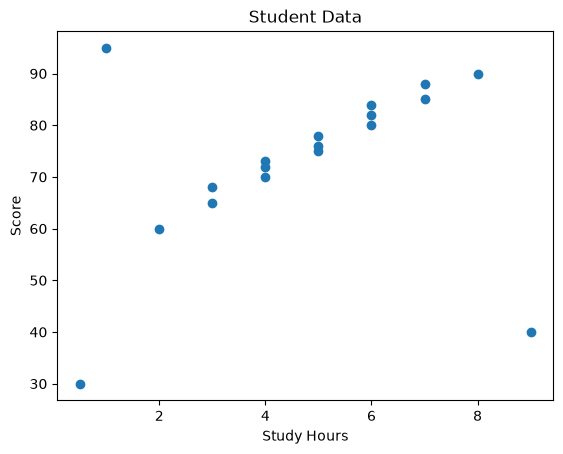

In [3]:
plt.scatter(df["study_hours"], df["score"])
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.title("Student Data")
plt.show()

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
model = IsolationForest(
    contamination=0.15,
    random_state=42
)

model.fit(X_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.15
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [6]:
pred = model.predict(X_scaled)

print(pred)

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1]


In [7]:
df["anomaly"] = pred

df

,study_hours,score,anomaly
0,2.0,60.0,1
1,3.0,65.0,1
2,4.0,70.0,1
3,5.0,75.0,1
4,6.0,80.0,1
5,7.0,85.0,1
6,8.0,90.0,1
7,5.0,78.0,1
8,6.0,82.0,1
9,4.0,72.0,1


In [8]:
df[df["anomaly"] == -1]

,study_hours,score,anomaly
15,1.0,95.0,-1
16,9.0,40.0,-1
17,0.5,30.0,-1


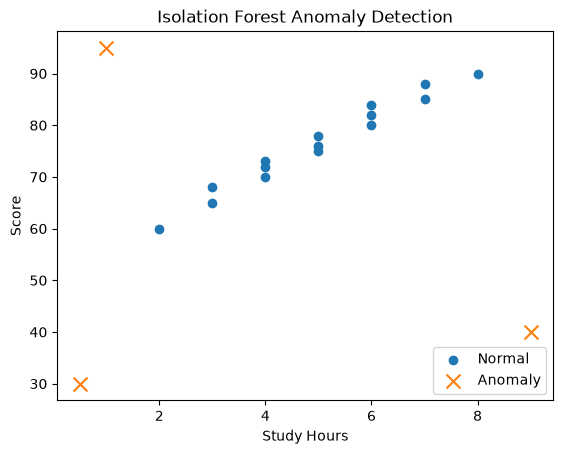

In [9]:
normal = df[df["anomaly"] == 1]
anomaly = df[df["anomaly"] == -1]

plt.scatter(
    normal["study_hours"],
    normal["score"],
    label="Normal"
)

plt.scatter(
    anomaly["study_hours"],
    anomaly["score"],
    label="Anomaly",
    marker="x",
    s=100
)

plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.title("Isolation Forest Anomaly Detection")
plt.legend()
plt.show()

In [10]:
true_labels = np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    -1, -1, -1
])

print(confusion_matrix(true_labels, pred))
print(classification_report(true_labels, pred))

[[ 3  0]
 [ 0 15]]
              precision    recall  f1-score   support

          -1       1.00      1.00      1.00         3
           1       1.00      1.00      1.00        15

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



In [11]:
scores = model.decision_function(X_scaled)

df["anomaly_score"] = scores

df

,study_hours,score,anomaly,anomaly_score
0,2.0,60.0,1,0.046608
1,3.0,65.0,1,0.127526
2,4.0,70.0,1,0.163109
3,5.0,75.0,1,0.182461
4,6.0,80.0,1,0.156524
5,7.0,85.0,1,0.137658
6,8.0,90.0,1,0.030838
7,5.0,78.0,1,0.172295
8,6.0,82.0,1,0.174729
9,4.0,72.0,1,0.182711


In [12]:
contamination_values = [0.05, 0.1, 0.15, 0.2, 0.3]

for c in contamination_values:
    model = IsolationForest(
        contamination=c,
        random_state=42
    )

    model.fit(X_scaled)
    pred = model.predict(X_scaled)

    anomaly_count = np.sum(pred == -1)

    print(f"contamination={c}, 检测出的异常数量={anomaly_count}")

contamination=0.05, 检测出的异常数量=1
contamination=0.1, 检测出的异常数量=2
contamination=0.15, 检测出的异常数量=3
contamination=0.2, 检测出的异常数量=4
contamination=0.3, 检测出的异常数量=6


In [13]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
model = IsolationForest(
    contamination=0.1,
    random_state=42
)

model.fit(X_scaled)

pred = model.predict(X_scaled)

In [16]:
print("正常样本数量：", np.sum(pred == 1))
print("异常样本数量：", np.sum(pred == -1))

正常样本数量： 512
异常样本数量： 57


In [17]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y
df["anomaly"] = pred

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,anomaly
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,-1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,-1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,1


In [18]:
df[df["anomaly"] == -1].head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,anomaly
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0,-1
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,0,-1
9,12.46,24.04,83.97,475.9,0.1186,0.2396,0.2273,0.08543,0.2030,0.08243,...,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.2075,0,-1
12,19.17,24.80,132.40,1123.0,0.0974,0.2458,0.2065,0.11180,0.2397,0.07800,...,151.70,1332.0,0.1037,0.3903,0.3639,0.1767,0.3176,0.1023,0,-1
25,17.14,16.40,116.00,912.7,0.1186,0.2276,0.2229,0.14010,0.3040,0.07413,...,152.40,1461.0,0.1545,0.3949,0.3853,0.2550,0.4066,0.1059,0,-1
